In [1]:
import collections
import queue
import random
import matplotlib.pyplot as plt

# Настройка вывода графиков прямо в ноутбуке
%matplotlib inline

# Структура для хранения событий
Event = collections.namedtuple('Event', 'time ident action')

# Глобальные константы моделирования
DEPARTURE_INTERVAL = 5  # Интервал между выездами машин из гаража

## 1. Вспомогательная функция расчёта времени

Время поиска пассажира и время поездки имеют **экспоненциальное распределение**.
* Среднее время поиска пассажира — 5 минут.
* Среднее время поездки с пассажиром — 15 минут.

In [2]:
def compute_duration(previous_action):
    """
    Вычисляет длительность следующего действия на основе экспоненциального распределения.
    """
    if previous_action in ['выехал из гаража', 'высадил пассажира']:
        return max(1, round(random.expovariate(1 / 5)))
    elif previous_action == 'посадил пассажира':
        return max(1, round(random.expovariate(1 / 15)))
    return 0

In [3]:
def taxi_process(ident, trips, start_time=0):
    """
    Сопрограмма (корутина), моделирующая жизненный цикл одного такси.
    """
    # Инициализация счетчиков статистики (Задание 1)
    trip_count = 0
    total_passenger_time = 0
    total_search_time = 0

    # Такси выезжает и сразу начинает искать пассажира
    search_start = start_time
    time = yield Event(start_time, ident, 'выехал из гаража')

    for i in range(trips):
        # 1. Пассажир сел в машину
        search_duration = time - search_start
        total_search_time += search_duration

        ride_start = time
        time = yield Event(time, ident, 'посадил пассажира')

        # 2. Пассажир вышел из машины
        ride_duration = time - ride_start
        total_passenger_time += ride_duration
        trip_count += 1

        search_start = time
        time = yield Event(time, ident, 'высадил пассажира')

    # Вывод статистики при завершении работы перед уходом в гараж
    print(f"\n[Статистика Такси #{ident}]:")
    print(f"  - Совершено поездок: {trip_count}")
    print(f"  - Время с пассажирами: {total_passenger_time} мин.")
    print(f"  - Время в поиске: {total_search_time} мин.")

    yield Event(time, ident, 'уехал в гараж')

In [4]:
class Simulator:
    def __init__(self, procs_map):
        self.events = queue.PriorityQueue()
        self.procs = dict(procs_map)
        self.plot_data = []  # Список для сбора данных для графика

    def run(self, end_time):
        """Запуск главного цикла обработки событий."""
        # Планируем первое событие для каждого такси
        for proc_id, proc in sorted(self.procs.items()):
            first_event = next(proc)
            self.events.put(first_event)

        sim_time = 0
        while sim_time < end_time:
            if self.events.empty():
                print('\n*** События закончились! ***')
                break

            current_event = self.events.get()
            sim_time, proc_id, previous_action = current_event

            # Логирование процесса в реальном времени
            indent = "    " * proc_id
            print(f"Время {sim_time:3d} | {indent}такси {proc_id}: {previous_action}")

            # Фиксируем моменты поездок для графика
            if previous_action in ['посадил пассажира', 'высадил пассажира']:
                self.plot_data.append((proc_id, sim_time, previous_action))

            active_proc = self.procs[proc_id]
            next_time = sim_time + compute_duration(previous_action)

            try:
                next_event = active_proc.send(next_time)
            except StopIteration:
                del self.procs[proc_id]
            else:
                self.events.put(next_event)
        else:
            print(f'\n*** Время истекло: {self.events.qsize()} событий осталось в очереди ***')

    def plot_results(self):
        """Построение графика поездок."""
        if not self.plot_data:
            print("Нет данных для построения графика.")
            return

        starts_x = [time for ident, time, action in self.plot_data if action == 'посадил пассажира']
        starts_y = [ident for ident, time, action in self.plot_data if action == 'посадил пассажира']
        ends_x = [time for ident, time, action in self.plot_data if action == 'высадил пассажира']
        ends_y = [ident for ident, time, action in self.plot_data if action == 'высадил пассажира']

        plt.figure(figsize=(14, 6))
        plt.scatter(starts_x, starts_y, color='green', marker='^', s=120, label='Посадка')
        plt.scatter(ends_x, ends_y, color='red', marker='v', s=120, label='Высадка')

        taxis_set = set(ident for ident, _, _ in self.plot_data)
        for t_id in taxis_set:
            t_events = sorted([item for item in self.plot_data if item[0] == t_id], key=lambda x: x[1])
            for i in range(len(t_events) - 1):
                if t_events[i][2] == 'посадил пассажира' and t_events[i+1][2] == 'высадил пассажира':
                    plt.plot([t_events[i][1], t_events[i+1][1]], [t_id, t_id], color='gray', linestyle='-', alpha=0.5)

        plt.xlabel('Модельное время (минуты)', fontsize=12)
        plt.ylabel('Идентификатор такси (ID)', fontsize=12)
        plt.title('График работы такси (Моменты поездок)', fontsize=14)
        plt.yticks(list(taxis_set))
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc='upper left')
        plt.show()

Запуск имитационного моделирования такси (4 машин)
Время   0 | такси 0: выехал из гаража
Время   5 | такси 0: посадил пассажира
Время   5 |     такси 1: выехал из гаража
Время   6 | такси 0: высадил пассажира
Время   7 | такси 0: посадил пассажира
Время   7 |     такси 1: посадил пассажира
Время  10 |         такси 2: выехал из гаража
Время  15 |             такси 3: выехал из гаража
Время  16 |             такси 3: посадил пассажира
Время  21 |         такси 2: посадил пассажира
Время  22 |         такси 2: высадил пассажира
Время  23 |         такси 2: посадил пассажира
Время  24 |     такси 1: высадил пассажира
Время  24 |             такси 3: высадил пассажира
Время  25 |     такси 1: посадил пассажира
Время  25 |             такси 3: посадил пассажира
Время  27 | такси 0: высадил пассажира
Время  28 | такси 0: посадил пассажира
Время  34 |         такси 2: высадил пассажира
Время  37 |             такси 3: высадил пассажира
Время  38 |             такси 3: посадил пассажира
Время 

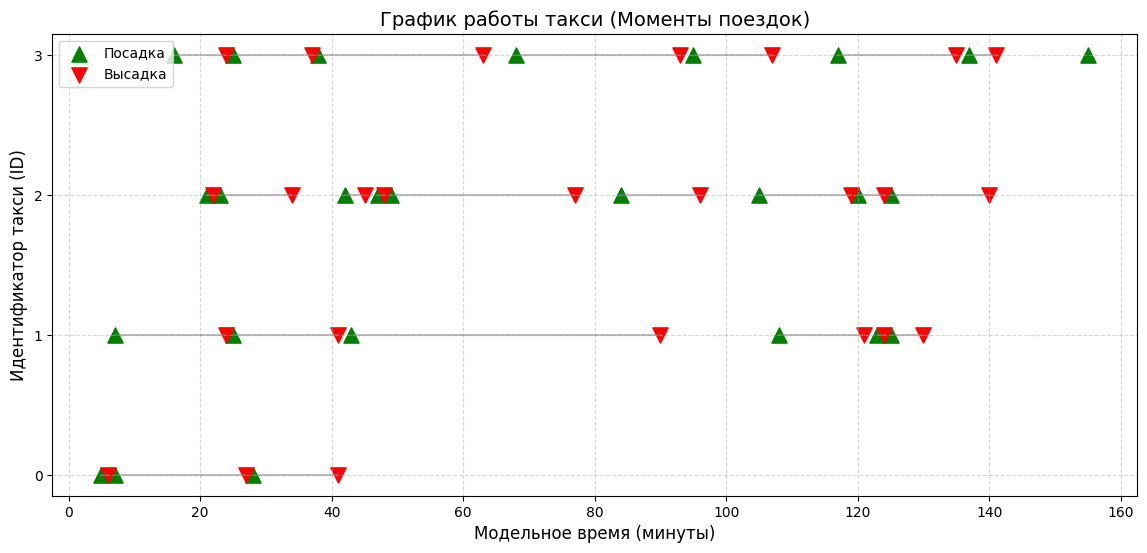

In [5]:
random.seed(42)

# ПАРАМЕТРЫ ДЛЯ НАСТРОЙКИ (Задание 2):
num_taxis = 4
max_simulation_time = 150

# Динамическая генерация процессов
taxis = {
    i: taxi_process(i, trips=(i + 1) * 3, start_time=i * DEPARTURE_INTERVAL)
    for i in range(num_taxis)
}

print(f"Запуск имитационного моделирования такси ({num_taxis} машин)")
sim = Simulator(taxis)
sim.run(max_simulation_time)


sim.plot_results()

Запуск имитационного моделирования такси (3 машин)
Время   0 | такси 0: выехал из гаража
Время   5 | такси 0: посадил пассажира
Время   5 |     такси 1: выехал из гаража
Время   6 | такси 0: высадил пассажира
Время   7 | такси 0: посадил пассажира
Время   7 |     такси 1: посадил пассажира
Время  10 |         такси 2: выехал из гаража
Время  21 |         такси 2: посадил пассажира
Время  22 |         такси 2: высадил пассажира
Время  24 |     такси 1: высадил пассажира
Время  25 |     такси 1: посадил пассажира
Время  25 |         такси 2: посадил пассажира
Время  27 | такси 0: высадил пассажира
Время  28 | такси 0: посадил пассажира
Время  29 |     такси 1: высадил пассажира
Время  31 | такси 0: высадил пассажира

[Статистика Такси #0]:
  - Совершено поездок: 3
  - Время с пассажирами: 24 мин.
  - Время в поиске: 7 мин.
Время  34 |     такси 1: посадил пассажира
Время  35 | такси 0: уехал в гараж
Время  36 |         такси 2: высадил пассажира
Время  38 |     такси 1: высадил пассажира

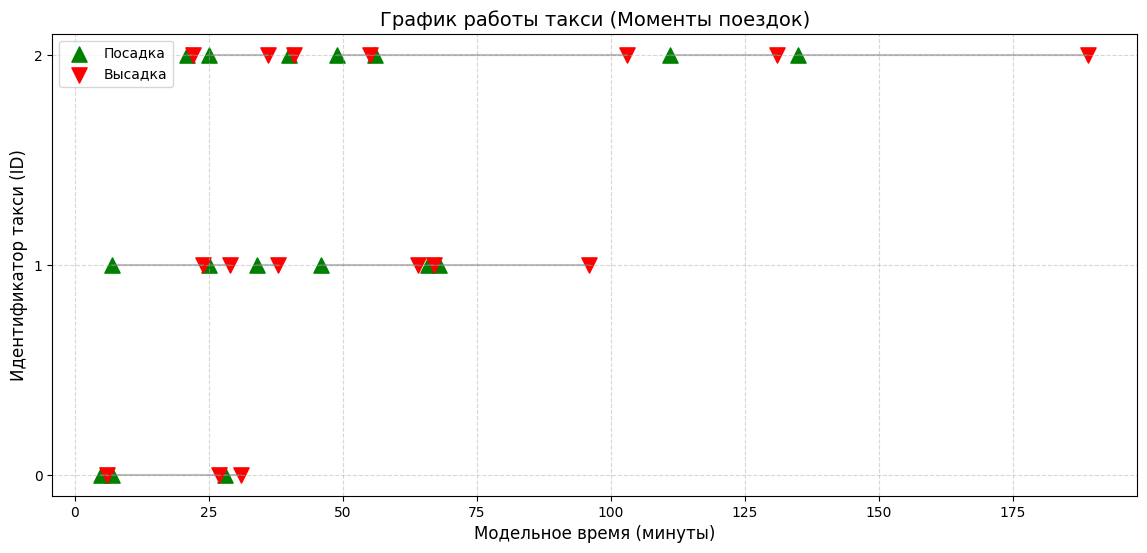

In [10]:
random.seed(42)

# ПАРАМЕТРЫ ДЛЯ НАСТРОЙКИ (Задание 2):
num_taxis = 3              # Количество машин
max_simulation_time = 150  # Лимит работы симулятора в минутах

# Динамическая генерация процессов по формуле из задания
taxis = {
    i: taxi_process(i, trips=(i + 1) * 3, start_time=i * DEPARTURE_INTERVAL)
    for i in range(num_taxis)
}

print(f"Запуск имитационного моделирования такси ({num_taxis} машин)")
sim = Simulator(taxis)
sim.run(max_simulation_time)

sim.plot_results()

Запуск имитационного моделирования такси (8 машин)
Время   0 | такси 0: выехал из гаража
Время   5 | такси 0: посадил пассажира
Время   5 |     такси 1: выехал из гаража
Время   6 | такси 0: высадил пассажира
Время   7 | такси 0: посадил пассажира
Время   7 |     такси 1: посадил пассажира
Время  10 |         такси 2: выехал из гаража
Время  15 |             такси 3: выехал из гаража
Время  16 |             такси 3: посадил пассажира
Время  20 |                 такси 4: выехал из гаража
Время  21 |         такси 2: посадил пассажира
Время  21 |                 такси 4: посадил пассажира
Время  24 |     такси 1: высадил пассажира
Время  24 |             такси 3: высадил пассажира
Время  25 |     такси 1: посадил пассажира
Время  25 |         такси 2: высадил пассажира
Время  25 |             такси 3: посадил пассажира
Время  25 |                     такси 5: выехал из гаража
Время  27 | такси 0: высадил пассажира
Время  29 |         такси 2: посадил пассажира
Время  29 |             так

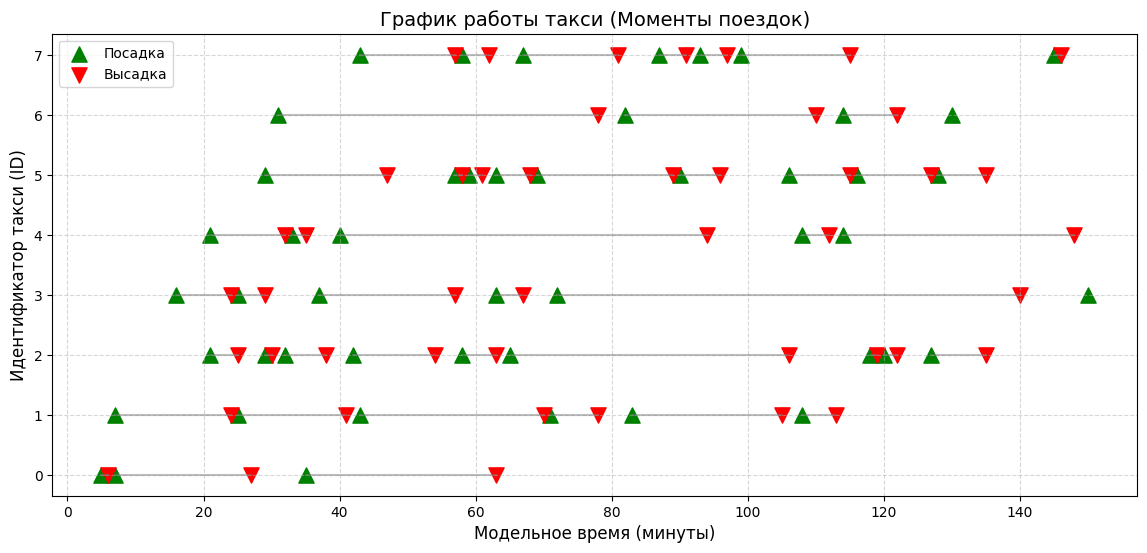

In [11]:
random.seed(42)

# ПАРАМЕТРЫ ДЛЯ НАСТРОЙКИ (Задание 2):
num_taxis = 8              # Количество машин
max_simulation_time = 150  # Лимит работы симулятора в минутах

# Динамическая генерация процессов по формуле из задания
taxis = {
    i: taxi_process(i, trips=(i + 1) * 3, start_time=i * DEPARTURE_INTERVAL)
    for i in range(num_taxis)
}

print(f"Запуск имитационного моделирования такси ({num_taxis} машин)")
sim = Simulator(taxis)
sim.run(max_simulation_time)

sim.plot_results()

Вариант с 3 такси: Нагрузка минимальна. Такси №0 и №1 полностью выполнили свои планы поездок и успешно уехали в гараж. Такси №2 завершило последнюю высадку на 189-й минуте, и в очереди осталось всего 1 событие (уход в гараж).Вариант с 4 такси: Оптимальный баланс для заданного времени. Три машины (№0, №1, №2) полностью завершили смену. В очереди осталось 1 событие для последней машины (№3), которая не успела выполнить свой объем.Вариант с 8 такси: Наблюдается перегрузка временного лимита. Успешно завершить работу успели только первые три машины (№0, №1, №2). Симуляция прервалась, оставив в очереди 5 событий, так как старшие ID такси (например, №7) имеют слишком большой объем работы ($(7+1) \times 3 = 24$ поездки) и физически не успевают отработать их за 150 минут.